In [31]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import  timedelta, datetime
import matplotlib.pyplot as plt
plt.style.use('dark_background')


In [32]:
mt5.initialize()

True

In [33]:
mt5.history_deals_get(datetime(2024,6,30),datetime.now(), symbol ="XAUUSD")

(TradeDeal(ticket=2597153941, order=0, time=1720378406, time_msc=1720378406981, type=2, entry=0, magic=0, position_id=0, reason=0, volume=0.0, price=0.0, commission=0.0, swap=0.0, profit=100000.0, fee=0.0, symbol='', comment='', external_id=''),
 TradeDeal(ticket=2605052763, order=2630081407, time=1720556149, time_msc=1720556149614, type=1, entry=0, magic=100922, position_id=2630081407, reason=3, volume=0.01, price=2359.7, commission=0.0, swap=0.0, profit=0.0, fee=0.0, symbol='XAUUSD', comment='grid_trading_bot', external_id=''),
 TradeDeal(ticket=2605058617, order=2630087294, time=1720556263, time_msc=1720556263718, type=0, entry=1, magic=100922, position_id=2630081407, reason=4, volume=0.01, price=2360.45, commission=0.0, swap=0.0, profit=-0.75, fee=0.0, symbol='XAUUSD', comment='[sl 2360.45]', external_id=''),
 TradeDeal(ticket=2605065548, order=2630094334, time=1720556424, time_msc=1720556424327, type=1, entry=0, magic=100922, position_id=2630094334, reason=3, volume=0.02, price=23

In [34]:
martingale_xau_data = mt5.history_deals_get(datetime(2024,7,11),(datetime.now() + timedelta(hours=3)), symbol ="XAUUSD")
data = {
    'time': [datetime.fromtimestamp(deal.time) for deal in martingale_xau_data],
    'ticket': [deal.ticket for deal in martingale_xau_data],
    'profit': [deal.profit for deal in martingale_xau_data],
    'swap': [deal.swap for deal in martingale_xau_data],
    'volume': [deal.volume for deal in martingale_xau_data],
    'symbol': [deal.symbol for deal in martingale_xau_data]
}
data = pd.DataFrame(data)
martingale_xau = data[data['symbol'] == 'XAUUSD']
martingale_xau = martingale_xau[martingale_xau['profit'] != 0]


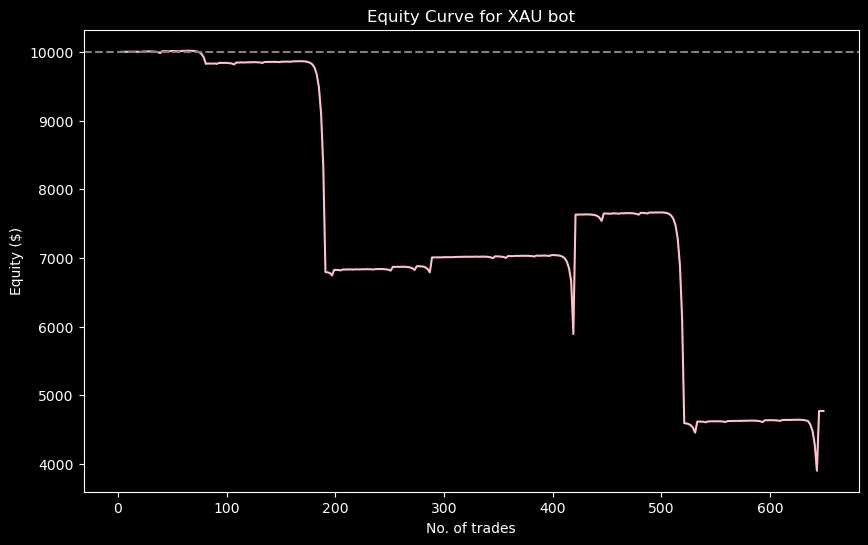

In [35]:
equity = np.cumsum(martingale_xau['profit']) + 10000 
plt.figure(figsize=(10, 6))
plt.plot(martingale_xau.index, equity, color='pink')
plt.axhline(y=10000, color='gray', linestyle='--')  # Add a horizontal dotted line at y=6000
plt.xlabel('No. of trades')
plt.ylabel('Equity ($)')
plt.title('Equity Curve for XAU bot')
plt.grid(False)
plt.show()